# 01 — Map-matching sanity check

Visual inspection of `LeuvenMapMatcher` on the committed fixtures (design §13.3:
eyeball 5–10 matched trajectories before trusting the matcher at scale). Everything
here runs **offline** from `tests/fixtures/` — no OSM download.

- Network: `beijing_fixture` (183 nodes / 388 edges, EPSG:32650)
- Trajectories: 8 road-following synthetic traces (`tests/fixtures/geolife_onroad/`)
  plus one off-road random walk as a negative control.


In [1]:
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from pyproj import Transformer

from trajguard.datasets.cleaning import CleaningConfig, clean
from trajguard.datasets.geolife import GeolifeLoader
from trajguard.maps.osm import OSMMapSource
from trajguard.matching.base import match_many
from trajguard.matching.leuven import LeuvenMapMatcher

logging.disable(logging.WARNING)  # silence leuven's linear-search notices

FIXTURES = Path("..") / "tests" / "fixtures"
net = OSMMapSource(
    region="beijing_fixture",
    bbox=(116.30, 39.98, 116.32, 39.995),
    crs="EPSG:32650",
    out_dir=FIXTURES / "maps",
).load()
cfg = CleaningConfig()
matcher = LeuvenMapMatcher()  # radius_m=50, gps_error_m=20, k_candidates=8
to_xy = Transformer.from_crs("EPSG:4326", net.crs, always_xy=True)
print(f"network: {len(net.nodes)} nodes, {len(net.edges)} edges, {net.crs}")

network: 183 nodes, 388 edges, EPSG:32650


## Match quality table

`match_score = frac_matched * exp(-mean_offset / (2 * gps_error_m))`; trajectories
under `min_match_score = 0.6` (design §8) are dropped. `leuven_prob` is the
matcher-native normalized probability, shown for calibration reference.

In [2]:
WALK_ID = "geolife/001/20081026103000"
loader = GeolifeLoader(FIXTURES / "geolife_onroad")
cleaned = [clean(r, cfg) for r in loader.iter_trajectories()]
walk_raw = next(
    r for r in GeolifeLoader(FIXTURES / "geolife").iter_trajectories() if r.traj_id == WALK_ID
)
cleaned.append(clean(walk_raw, cfg))

rows, results = [], {}
for traj in cleaned:
    m = matcher.match(traj, net)
    results[traj.traj_id] = (traj, m)
    q = matcher.quality(m)
    rows.append(
        {
            "traj_id": traj.traj_id,
            "points": len(traj.points),
            "frac_matched": round(m.frac_matched, 3),
            "mean_offset_m": round(q["mean_offset_m"], 1),
            "max_offset_m": round(q["max_offset_m"], 1),
            "n_edges": int(q["n_edges"]),
            "match_score": round(m.match_score, 3),
            "kept@0.6": m.match_score >= 0.6,
        }
    )
kept, dropped = match_many(matcher, cleaned, net, min_match_score=0.6)
table = pd.DataFrame(rows)
print(f"kept {len(kept)} / dropped {dropped} at min_match_score=0.6")
table

kept 8 / dropped 1 at min_match_score=0.6


,traj_id,points,frac_matched,mean_offset_m,max_offset_m,n_edges,match_score,kept@0.6
0,geolife/005/20081201080000,29,1.000,4.9,19.9,9,0.886,True
1,geolife/005/20081202080000,117,1.000,5.3,45.4,22,0.877,True
2,geolife/005/20081203080000,95,1.000,3.3,43.8,19,0.921,True
3,geolife/005/20081204080000,27,1.000,3.3,12.5,7,0.921,True
4,geolife/006/20081205080000,29,1.000,2.3,5.1,10,0.943,True
5,geolife/006/20081206080000,70,1.000,3.8,42.6,13,0.909,True
6,geolife/006/20081207080000,103,1.000,3.9,26.0,22,0.908,True
7,geolife/006/20081208080000,34,1.000,2.9,11.5,13,0.930,True
8,geolife/001/20081026103000,40,0.025,2.0,2.0,1,0.024,False


## Overview — all matched trajectories on the network

Gray = road network; colored lines = snapped (matched) paths.

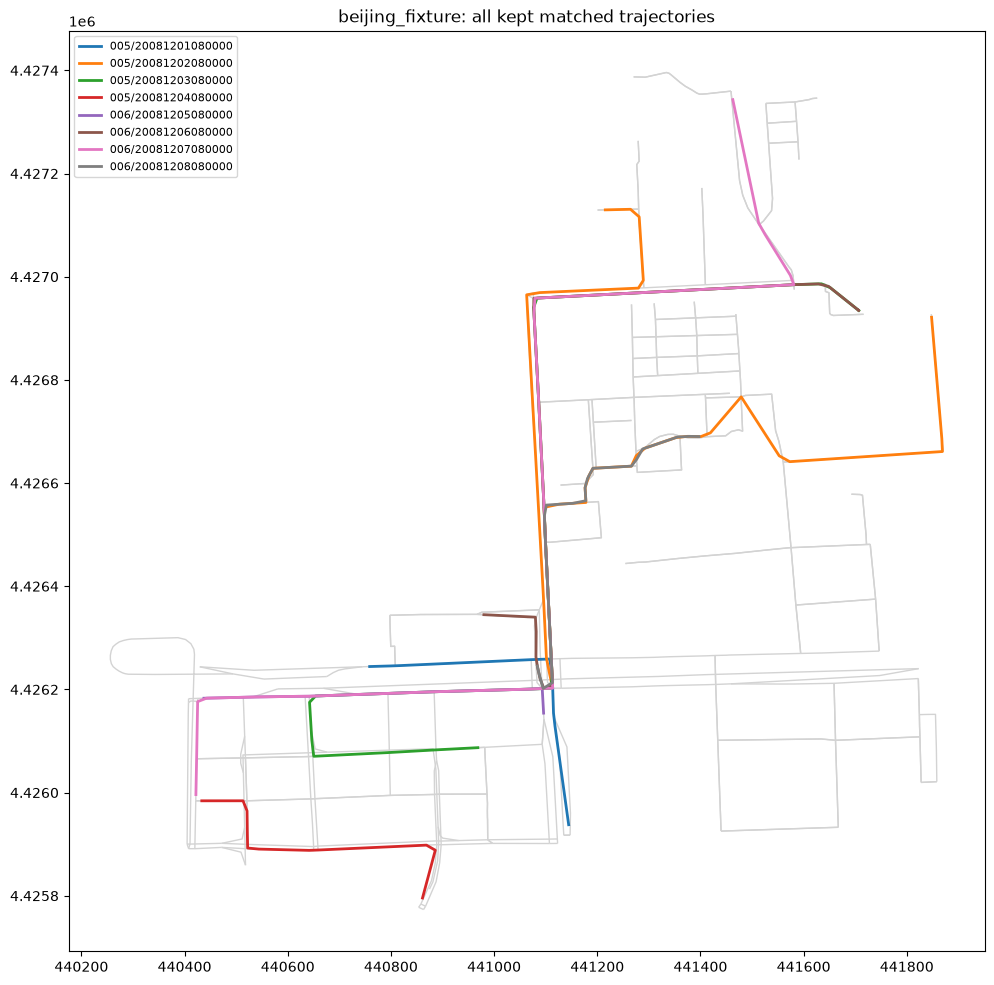

In [3]:
fig, ax = plt.subplots(figsize=(10, 10))
net.edges.plot(ax=ax, color="lightgray", linewidth=1, zorder=1)
cmap = plt.colormaps["tab10"]
for i, m in enumerate(kept):
    xs = [p[0] for p in m.matched_points]
    ys = [p[1] for p in m.matched_points]
    ax.plot(xs, ys, "-", color=cmap(i % 10), linewidth=2, label=m.traj_id.split("/", 1)[1])
ax.set_title("beijing_fixture: all kept matched trajectories")
ax.set_aspect("equal")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()

## Per-trajectory panels — raw GPS vs snapped path

Blue dots = raw GPS observations (projected); red line = matched path on the road
graph. The GPS dots should hug the red line; offsets are the σ≈3 m fixture noise.

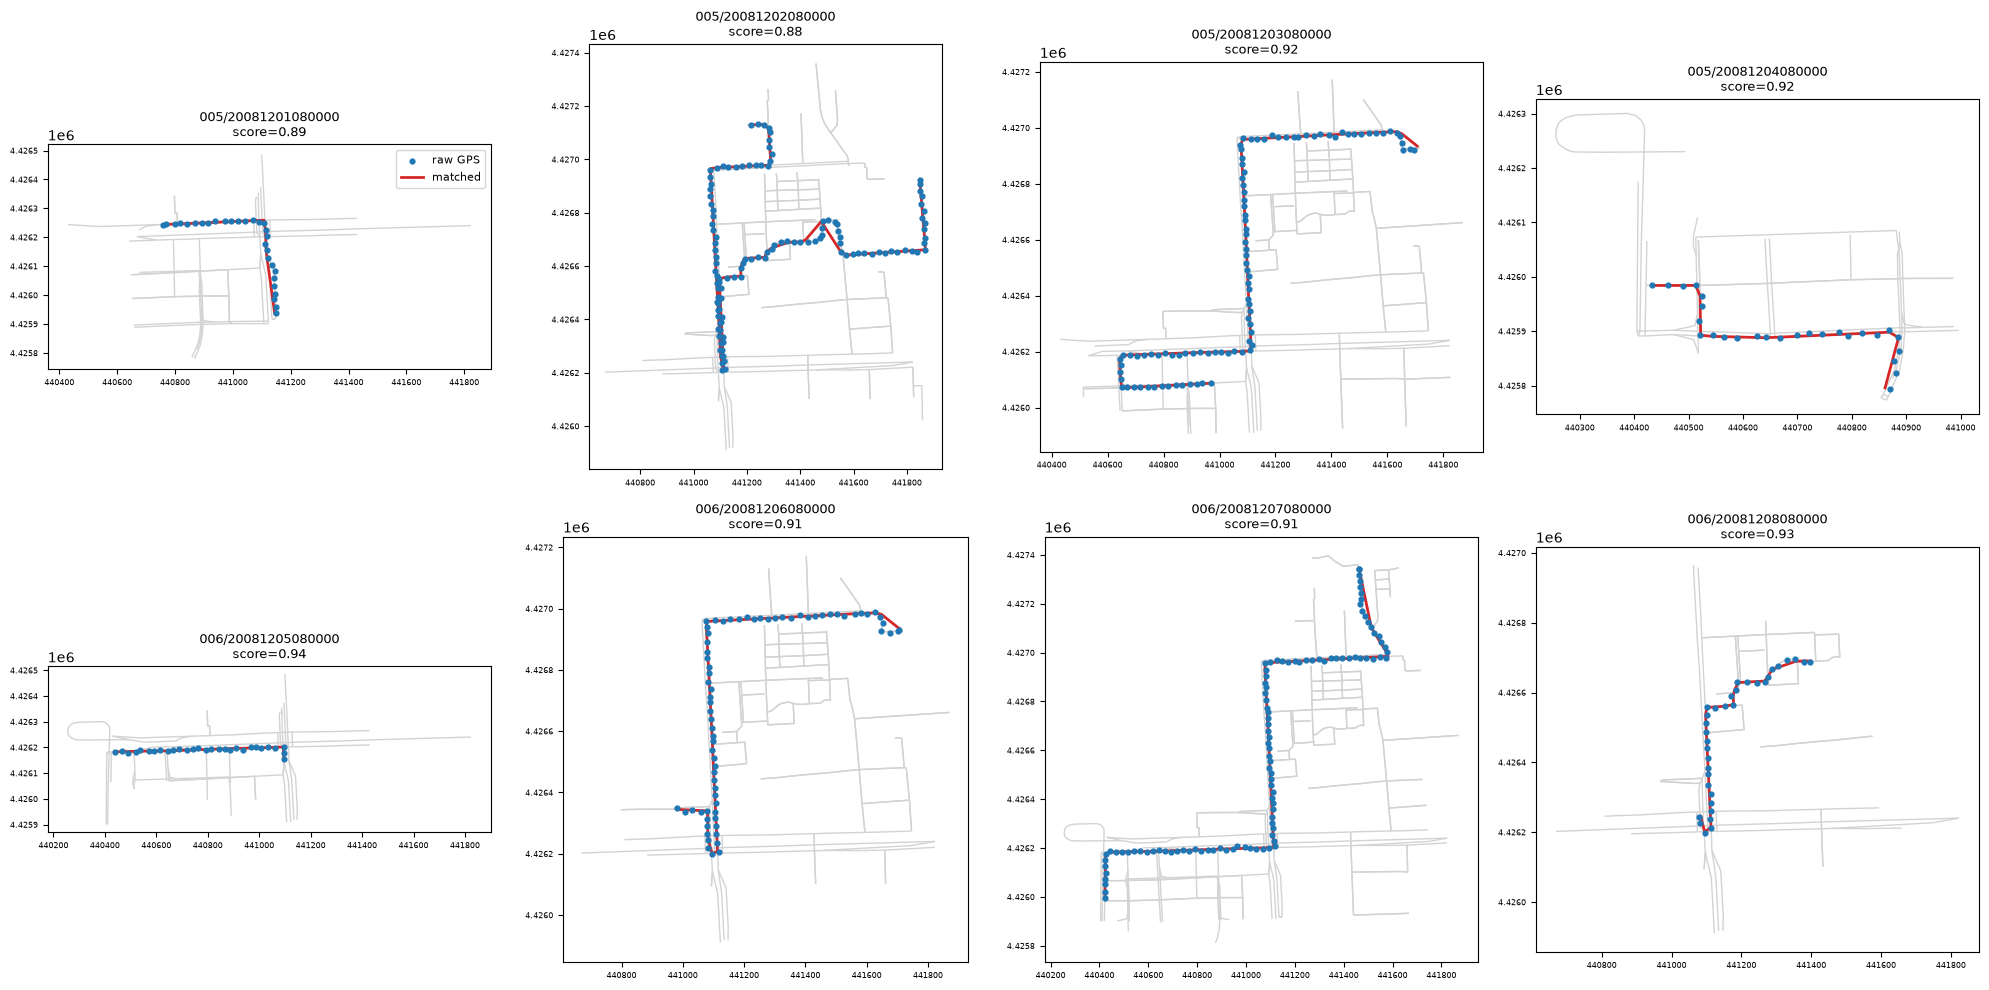

In [4]:
show = [(tid, tm) for tid, tm in results.items() if tid != WALK_ID][:8]
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, (tid, (traj, m)) in zip(axes.flat, show, strict=False):
    xs = [p[0] for p in m.matched_points]
    ys = [p[1] for p in m.matched_points]
    pad = 80
    net.edges.cx[min(xs) - pad : max(xs) + pad, min(ys) - pad : max(ys) + pad].plot(
        ax=ax, color="lightgray", linewidth=1, zorder=1
    )
    gx, gy = zip(*[to_xy.transform(lon, lat) for lat, lon, _ in traj.points], strict=False)
    ax.scatter(gx, gy, s=12, color="tab:blue", zorder=3, label="raw GPS")
    ax.plot(xs, ys, "-", color="tab:red", linewidth=2, zorder=2, label="matched")
    ax.set_title(f"{tid.split('/', 1)[1]}\nscore={m.match_score:.2f}", fontsize=9)
    ax.set_aspect("equal")
    ax.tick_params(labelsize=6)
axes.flat[0].legend(fontsize=8)
plt.tight_layout()

## Negative control — off-road random walk

A P1 random-walk fixture that ignores streets: the matcher can only anchor a tiny
prefix, `frac_matched` collapses and the trajectory is (correctly) dropped at 0.6.

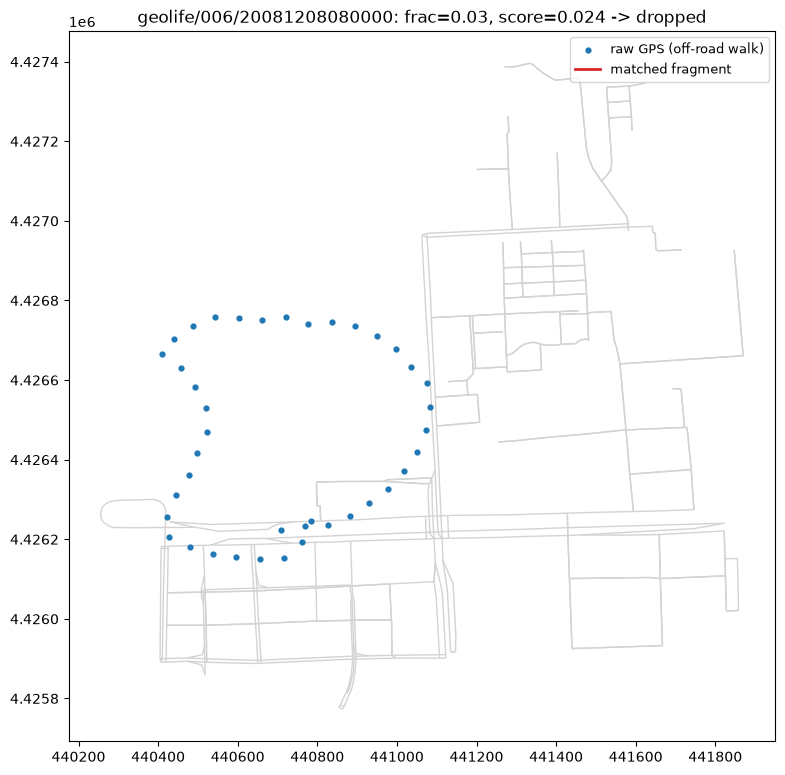

In [5]:
traj, m = results[WALK_ID]
fig, ax = plt.subplots(figsize=(8, 8))
net.edges.plot(ax=ax, color="lightgray", linewidth=1, zorder=1)
gx, gy = zip(*[to_xy.transform(lon, lat) for lat, lon, _ in traj.points], strict=False)
ax.scatter(gx, gy, s=12, color="tab:blue", zorder=3, label="raw GPS (off-road walk)")
if m.matched_points:
    ax.plot(
        [p[0] for p in m.matched_points],
        [p[1] for p in m.matched_points],
        "-",
        color="tab:red",
        linewidth=2,
        zorder=2,
        label="matched fragment",
    )
ax.set_title(f"{tid}: frac={m.frac_matched:.2f}, score={m.match_score:.3f} -> dropped")
ax.set_aspect("equal")
ax.legend(fontsize=9)
plt.tight_layout()